**Previously on:** Lecture 19 fit a line and read off slope, intercept, and R². Lecture 20
showed why a model's own training score flatters it, and made overfitting happen live by
shrinking the training set until a high-degree polynomial fell apart. Today: the same moves,
on a pair you haven't seen fit before, then Quiz 4.

Today's topics:
* one full worked example -- load, fit, split, evaluate, diagnose -- start to finish
* spotting overfitting from an error curve, before being told it's there
* Quiz 4, in class, on exactly this skill set

> This is the third Examples + Quiz checkpoint (after L6 and L13), and the first built
> entirely on Module 2 material. Quiz 4 is given in class today; HW7 is due this week.

# The bar for today

**Given a new pair of columns you haven't seen fit before, can you fit a line, evaluate it
honestly with a held-out set, and -- critically -- recognize when a fancier-looking fit is
actually worse?** That's the whole spec, and it's also the spec for Quiz 4. Skill checklist,
on screen for the rest of class:

1. Fit a line with `scipy.stats.linregress` or `np.polyfit`, and read off slope/intercept/R².
2. Use a fitted model to predict `y` from a new `x` value.
3. Split data into train/test sets and explain *why* -- evaluate on data the model didn't see.
4. Compute an error metric (RMSE) on train vs. test separately.
5. Recognize overfitting from the pattern: train error keeps dropping, test error stops
   dropping or rises, as model complexity increases.
6. Explain in one sentence why a low-training-error model can still be a bad model.

No new syntax appears in today's example that isn't on this list.

# Worked example: a fresh pair, start to finish

Same `steels.csv`, but a pair Lectures 19-20 never touched: **0.2% Proof Stress predicting
Elongation** -- does a stronger alloy give up ductility to get there? Real engineering
tradeoff, real scatter.

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [1]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


In [2]:
import numpy as np
import matplotlib.pyplot as plt

steels = data.drop(index=626)   # same row-626 cleanup as L19/L20
steels[[' 0.2% Proof Stress (MPa)', ' Elongation (%)']].describe()

,0.2% Proof Stress (MPa),Elongation (%)
count,914.000000,914.000000
mean,328.009847,26.806346
std,131.573737,8.795892
min,27.000000,10.000000
25%,220.000000,20.250000
50%,290.000000,26.000000
75%,432.000000,31.000000
max,690.000000,78.000000


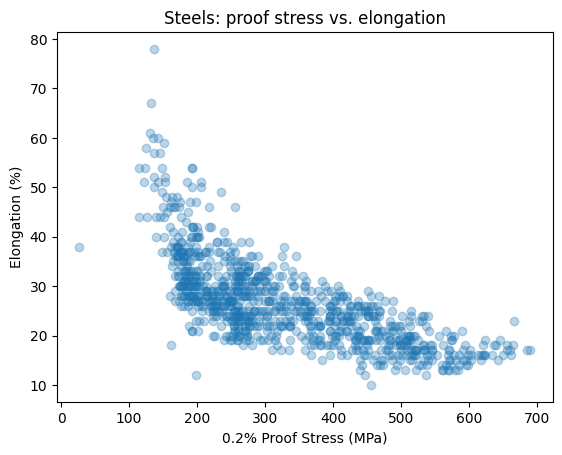

In [3]:
plt.scatter(steels[' 0.2% Proof Stress (MPa)'], steels[' Elongation (%)'], alpha=0.3)
plt.xlabel('0.2% Proof Stress (MPa)'); plt.ylabel('Elongation (%)')
plt.title('Steels: proof stress vs. elongation')
plt.show()

Does this look linear? Roughly -- negative slope, real scatter. That scatter is the whole
reason evaluation matters today.

In [4]:
x = steels[' 0.2% Proof Stress (MPa)'].values
y = steels[' Elongation (%)'].values

rng = np.random.default_rng(0)
shuffled = rng.permutation(len(x))
n_test = int(np.ceil(0.25 * len(x)))
idx_test, idx_train = shuffled[:n_test], shuffled[n_test:]

x_train, x_test = x[idx_train], x[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

coeffs = np.polyfit(x_train, y_train, deg=1)
y_pred_train = np.polyval(coeffs, x_train)
y_pred_test = np.polyval(coeffs, x_test)

def rmse(y_true, y_hat):
    return np.sqrt(np.mean((y_true - y_hat) ** 2))

print('train RMSE:', rmse(y_train, y_pred_train))
print('test RMSE:', rmse(y_test, y_pred_test))

train RMSE: 5.852676542044887
test RMSE: 7.022714964471369


Same idiom as Lecture 20's `split_train_test`: shuffle indices once, then use that *one*
shuffled order to slice both `x` and `y`. The hazard Lecture 20 flagged is shuffling `x` and
`y` independently -- two separate random draws that desync the pairing -- not calling the
shuffle once and reusing its result, which is exactly what happens here.

Fitting only ever touches `x_train`/`y_train`; `x_test`/`y_test` stay untouched until scoring
-- exactly Lecture 20's discipline. The two RMSEs come out close: a good, unremarkable linear
fit. That's the baseline the next step is about to be measured against.

Tempting-but-wrong idea: *"the line doesn't hit every point -- what if we let the model curve
more?"* Lecture 20 already taught us the honest version of this experiment: on the full
training set a single feature barely overfits at all, so to actually *see* it happen we
shrink the training set to 20 points, exactly like Section 5 did.

In [5]:
x_train_small, y_train_small = x_train[:20], y_train[:20]

degrees = [1, 2, 3, 5, 8]
train_errs, test_errs = [], []

for d in degrees:
    c = np.polyfit(x_train_small, y_train_small, deg=d)
    train_errs.append(rmse(y_train_small, np.polyval(c, x_train_small)))
    test_errs.append(rmse(y_test, np.polyval(c, x_test)))

for d, tr, te in zip(degrees, train_errs, test_errs):
    print(f'degree {d}: train RMSE = {tr:.2f}, test RMSE = {te:.2f}')

degree 1: train RMSE = 6.44, test RMSE = 7.65
degree 2: train RMSE = 5.44, test RMSE = 7.72
degree 3: train RMSE = 4.77, test RMSE = 14.56
degree 5: train RMSE = 3.53, test RMSE = 59.99
degree 8: train RMSE = 3.14, test RMSE = 14038.94


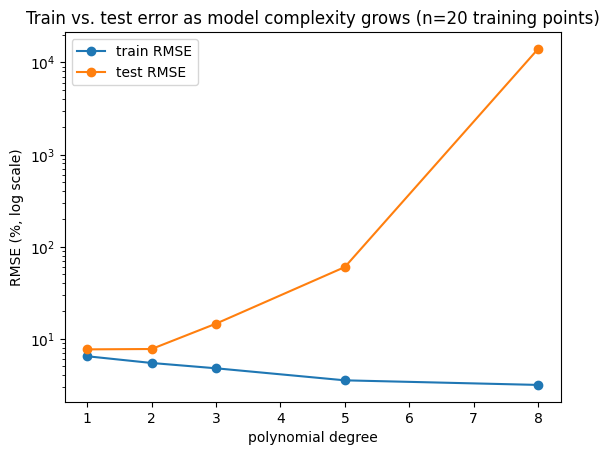

In [6]:
plt.plot(degrees, train_errs, 'o-', label='train RMSE')
plt.plot(degrees, test_errs, 'o-', label='test RMSE')
plt.yscale('log')
plt.xlabel('polynomial degree'); plt.ylabel('RMSE (%, log scale)')
plt.legend(); plt.title('Train vs. test error as model complexity grows (n=20 training points)')
plt.show()

**Diagnose it yourself before reading on:** which model has the lowest training error? Which
one would you actually trust to predict a new steel's elongation? Why are those different
answers?

Now the visual confirmation -- overlay the degree-1 and degree-8 fits on the full scatter:

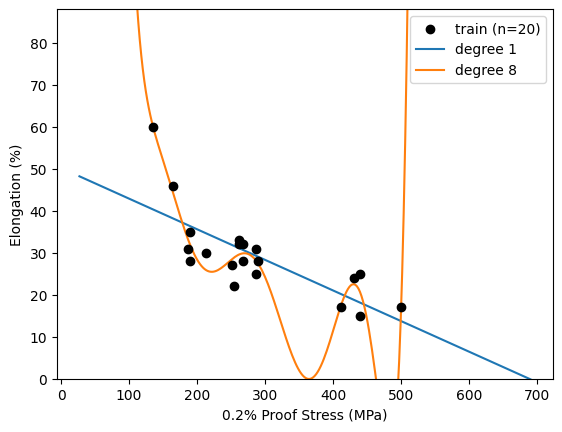

In [7]:
xx = np.linspace(x.min(), x.max(), 300)
c1 = np.polyfit(x_train_small, y_train_small, 1)
c8 = np.polyfit(x_train_small, y_train_small, 8)

plt.scatter(x_train_small, y_train_small, color='k', zorder=5, label='train (n=20)')
plt.plot(xx, np.polyval(c1, xx), label='degree 1')
plt.plot(xx, np.polyval(c8, xx), label='degree 8')
plt.ylim(y.min() - 10, y.max() + 10)   # keep the wild degree-8 wiggle from blowing out the axes
plt.legend(); plt.xlabel('0.2% Proof Stress (MPa)'); plt.ylabel('Elongation (%)')
plt.show()

The degree-8 curve visibly wiggles near the ends of the training range -- the payoff that
makes "low training error ≠ good model" concrete. Name the term now that it's been diagnosed
first, not told upfront: **overfitting** -- memorizing training noise instead of learning the
underlying trend.

# A preview: concrete

## Dataset: Concrete Compressive Strength

We'll use a dataset of concrete compressive strengths for our examples.

Each row represents a concrete mixture. The 8 input columns are component
amounts (kg/m³) and curing age (days). The output is measured compressive
strength in MPa.

> Reuse of this database is unlimited with retention of copyright notice for
> Prof. I-Cheng Yeh and the following published paper:
> I-Cheng Yeh, "Modeling of strength of high performance concrete using artificial
> neural networks," Cement and Concrete Research, Vol. 28, No. 12, pp. 1797-1808 (1998)

In [8]:
import pandas as pd
import numpy as np
import os

_file = 'concrete.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# set up features (X) and target (y)
x = data.loc[:, 'Cement (component 1)(kg in a m^3 mixture)':'Age (day)']
y = data.loc[:, 'Concrete compressive strength(MPa, megapascals) ']

print(f'{len(data)} samples, {x.shape[1]} features')
data

1030 samples, 8 features


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


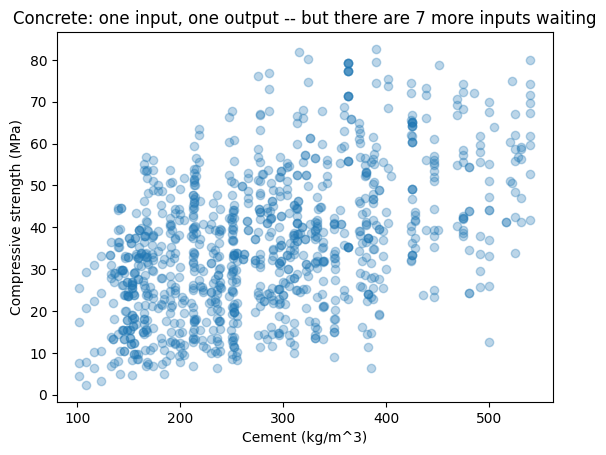

In [9]:
concrete = data
plt.scatter(concrete['Cement (component 1)(kg in a m^3 mixture)'],
            concrete['Concrete compressive strength(MPa, megapascals) '], alpha=0.3)
plt.xlabel('Cement (kg/m^3)'); plt.ylabel('Compressive strength (MPa)')
plt.title('Concrete: one input, one output -- but there are 7 more inputs waiting')
plt.show()

Cement content alone doesn't explain the scatter -- concrete strength depends on 8 components
at once, which is exactly why Lecture 23 moves to multivariate regression. Demo only, not
quiz-testable today.

# Rapid-fire recap: common mistakes

Back through the Section-1 checklist -- the single most common bug for each item:
* Fitting on the *entire* dataset, then "testing" on the same data used to fit -- defeats the
  whole purpose of a held-out set, and the single most common quiz failure mode historically.
* Reporting only training error and calling a model "good" because its training R² looked
  high.
* `np.polyfit`/`np.polyval` argument-order mixups (`polyfit(x, y, deg)` vs.
  `polyval(coeffs, x)`).
* Forgetting to seed the shuffle (`np.random.default_rng(0)`) and being confused when
  re-running a cell changes the answer -- reproducibility, first raised in Lecture 20.

# Quiz 4 (in class)

Quiz 4 is administered separately from this notebook -- closed-notes, ~20 minutes, scoped
exactly to the six-item checklist from the top of class. The quiz dataset is a small excerpt
of `steels.csv` on yet another column pair, so it tests skill transfer, not memorized numbers
from today. Expect: (1) fit a line and report slope/R², (2) explain in words why train/test
split matters, (3) given a printed train-error/test-error table across degrees, circle the row
that is overfit and justify it, (4) short-answer: why is low training error alone not evidence
of a good model?

# Wrap-up

* Fit -> split -> evaluate on held-out data -> compare complexity levels by test error, never
  training error alone.
* An overfit model is diagnosed from its *error curve* (train down, test flat-or-up), not from
  being told the word in advance.
* The whole Module 2 modeling toolkit so far -- `linregress`/`polyfit`, shuffle-and-split,
  RMSE, degree-cranking -- transfers unchanged to any new pair of columns.

**Take-home message:** the question "which model fits best?" only has an honest answer once
you've asked "best on data it never saw" -- everything else is a training-set magic trick.

Next time: Lecture 22 leaves polynomials behind and fits genuinely nonlinear functional forms
with `scipy.curve_fit` -- today you overfit a polynomial; next time you'll fit an equation
that actually comes from a physical model.